<a href="https://colab.research.google.com/github/Madu39627/Projects/blob/main/GWP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ================================
# Hyperparameter Optimization
# Models: SVM and Neural Network
# Dataset: Credit Card Fraud Detection
#
# Citation:
# Machine Learning Group - ULB. (2013). Credit Card Fraud Detection Dataset.
# Kaggle. https://www.kaggle.com/mlg-ulb/creditcardfraud
#
# The dataset was collected and analyzed during a research collaboration
# between Worldline and the Machine Learning Group (MLG) of
# Université Libre de Bruxelles (ULB) on big data mining and fraud detection.
#
# References:
# - Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015).
#   Calibrating Probability with Undersampling for Unbalanced Classification.
#   In 2015 IEEE Symposium Series on Computational Intelligence (pp. 159-166).
#   IEEE. https://doi.org/10.1109/SSCI.2015.33
#
# - Dal Pozzolo, A., Caelen, O., Le Borgne, Y. A., Waterschoot, S., &
#   Bontempi, G. (2014). Learned lessons in credit card fraud detection from
#   a practitioner perspective. Expert Systems with Applications, 41(10),
#   4915-4928. Pergamon.
# ================================
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load Credit Card Fraud Detection dataset
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Or use this direct link to load a sample
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

print("Loading financial dataset...")
df = pd.read_csv(url)

# Prepare features and target
X = df.drop('Class', axis=1)  # Features (V1-V28 are PCA components, Amount, Time)
y = df['Class']  # Target (0=legitimate, 1=fraud)

print(f"Dataset shape: {X.shape}")
print(f"Fraud cases: {y.sum()} ({y.sum()/len(y)*100:.2f}%)")
print(f"Legitimate cases: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.2f}%)")

# Due to dataset size, sample for faster training (optional)
# Remove this if you want to use full dataset
from sklearn.utils import resample
if len(df) > 50000:
    # Stratified sampling to maintain class balance
    df_sampled = resample(df, n_samples=50000, stratify=y, random_state=42)
    X = df_sampled.drop('Class', axis=1)
    y = df_sampled['Class']
    print(f"\nUsing sampled dataset: {X.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for SVM and Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------- SVM Hyperparameter Tuning --------
print("\n" + "="*50)
print("SVM Hyperparameter Optimization")
print("="*50)

svm = SVC(class_weight='balanced')  # Handle class imbalance
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    svm,
    svm_param_grid,
    cv=3,  # Reduced CV folds for faster training
    scoring='f1',  # F1 score better for imbalanced data
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print(f"\nBest SVM Parameters: {svm_grid.best_params_}")
print(f"Best SVM CV F1 Score: {svm_grid.best_score_:.4f}")

# Test set performance
svm_test_score = svm_grid.score(X_test_scaled, y_test)
print(f"SVM Test F1 Score: {svm_test_score:.4f}")

# -------- Neural Network Hyperparameter Tuning --------
print("\n" + "="*50)
print("Neural Network Hyperparameter Optimization")
print("="*50)

nn = MLPClassifier(max_iter=500, early_stopping=True, random_state=42)
nn_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001]  # L2 regularization
}

nn_grid = GridSearchCV(
    nn,
    nn_param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

nn_grid.fit(X_train_scaled, y_train)

print(f"\nBest NN Parameters: {nn_grid.best_params_}")
print(f"Best NN CV F1 Score: {nn_grid.best_score_:.4f}")

# Test set performance
nn_test_score = nn_grid.score(X_test_scaled, y_test)
print(f"NN Test F1 Score: {nn_test_score:.4f}")

# -------- Model Comparison --------
print("\n" + "="*50)
print("Model Comparison Summary")
print("="*50)
print(f"{'Model':<20} {'Best CV Score':<15} {'Test Score':<15}")
print("-"*50)
print(f"{'SVM':<20} {svm_grid.best_score_:<15.4f} {svm_test_score:<15.4f}")
print(f"{'Neural Network':<20} {nn_grid.best_score_:<15.4f} {nn_test_score:<15.4f}")

# Optional: Detailed classification report
from sklearn.metrics import classification_report

print("\n" + "="*50)
print("Best Model Detailed Performance (Test Set)")
print("="*50)

best_model = svm_grid if svm_test_score > nn_test_score else nn_grid
best_model_name = "SVM" if svm_test_score > nn_test_score else "Neural Network"

y_pred = best_model.predict(X_test_scaled)
print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

Loading financial dataset...
Dataset shape: (284807, 30)
Fraud cases: 492 (0.17%)
Legitimate cases: 284315 (99.83%)

Using sampled dataset: (50000, 30)

SVM Hyperparameter Optimization
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best SVM Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM CV F1 Score: 0.6706
SVM Test F1 Score: 0.3784

Neural Network Hyperparameter Optimization
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best NN Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
Best NN CV F1 Score: 0.8771
NN Test F1 Score: 0.7273

Model Comparison Summary
Model                Best CV Score   Test Score     
--------------------------------------------------
SVM                  0.6706          0.3784         
Neural Network       0.8771          0.7273         

Best Model Detailed Performance (Test Set)

Best Model: Neural Network

Classification Report:
              precision    recall  f1-score   sup

Loading financial dataset...
Original dataset shape: (284807, 30)
Fraud cases: 492 (0.17%)
Using sampled dataset: (30000, 30)

Generating SVM Learning Curve...


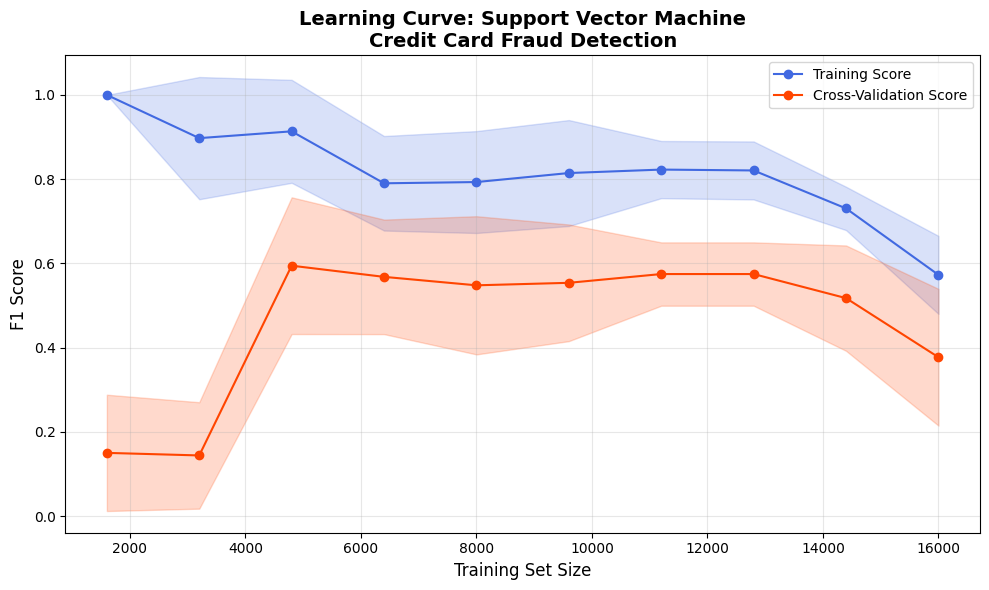

SVM - Final Training F1: 0.5729 (±0.0925)
SVM - Final Validation F1: 0.3774 (±0.1623)

Generating Neural Network Learning Curve...


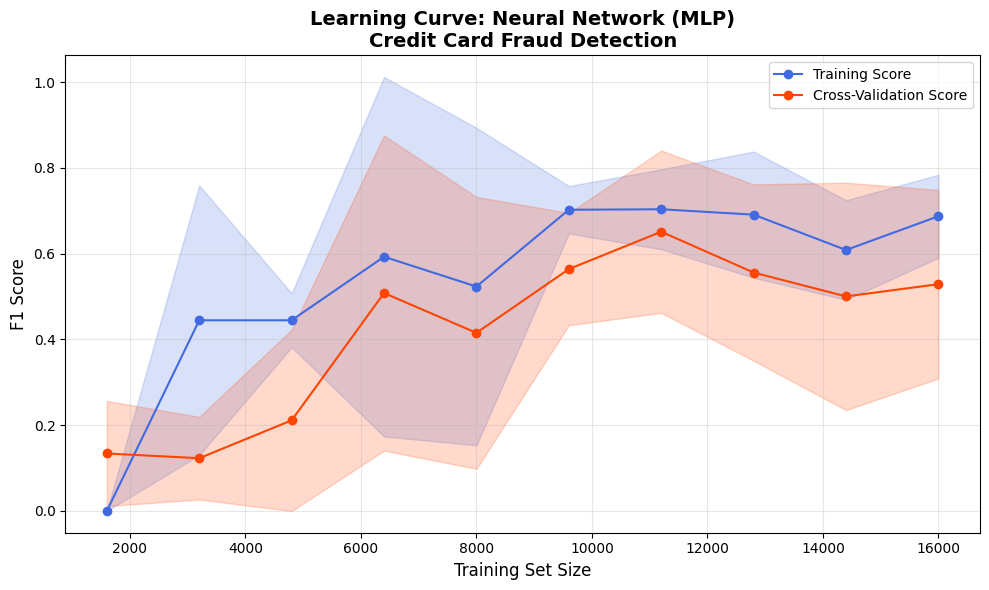

NN - Final Training F1: 0.6869 (±0.0969)
NN - Final Validation F1: 0.5286 (±0.2198)

Generating Neural Network Hyperparameter CV Plot...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


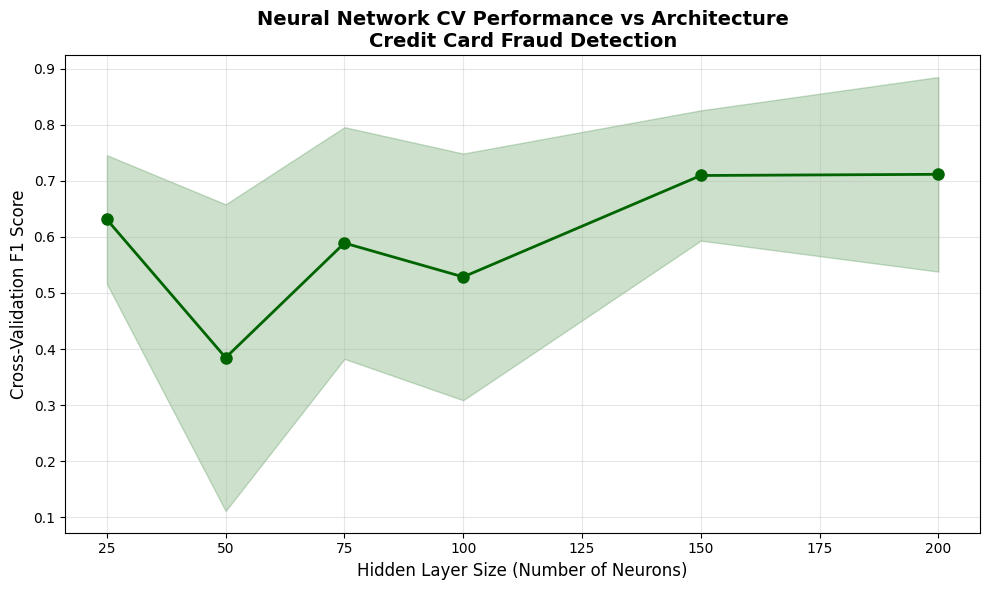


Best Hidden Layer Size: (200,)
Best CV F1 Score: 0.7114

Generating Model Comparison Plot...


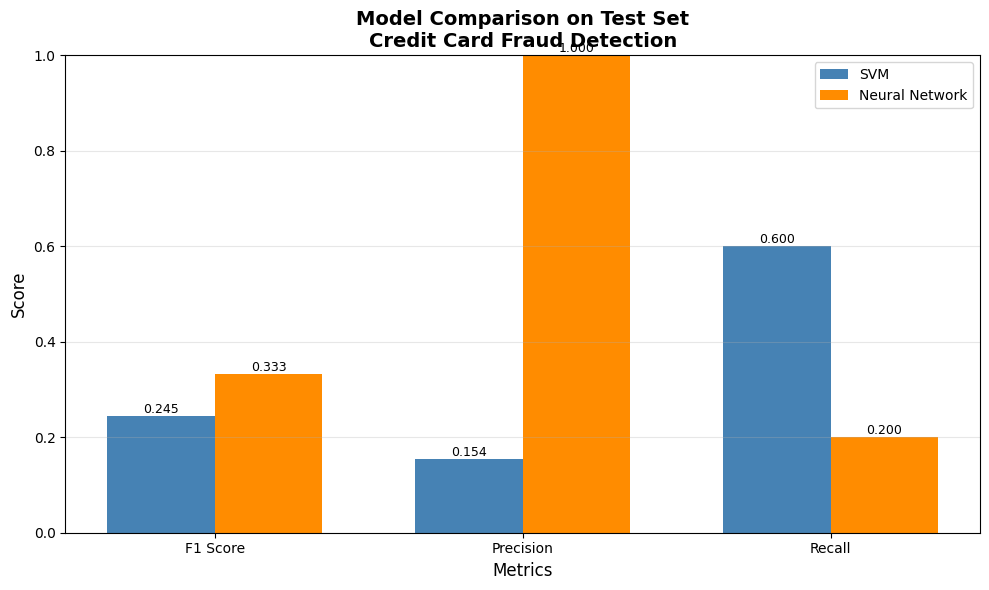


FINAL TEST SET PERFORMANCE
Model                F1 Score     Precision    Recall      
------------------------------------------------------------
SVM                  0.2449       0.1538       0.6000      
Neural Network       0.3333       1.0000       0.2000      

All plots saved successfully!
- svm_learning_curve.png
- nn_learning_curve.png
- nn_cv_performance.png
- model_comparison.png


In [4]:
# ================================
# Learning Curves and CV Plots
# Models: SVM and Neural Network
# Dataset: Credit Card Fraud Detection
#
# Citation:
# Machine Learning Group - ULB. (2013). Credit Card Fraud Detection Dataset.
# Kaggle. https://www.kaggle.com/mlg-ulb/creditcardfraud
#
# The dataset was collected and analyzed during a research collaboration
# between Worldline and the Machine Learning Group (MLG) of
# Université Libre de Bruxelles (ULB) on big data mining and fraud detection.
#
# References:
# - Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015).
#   Calibrating Probability with Undersampling for Unbalanced Classification.
#   In 2015 IEEE Symposium Series on Computational Intelligence (pp. 159-166).
#   IEEE. https://doi.org/10.1109/SSCI.2015.33
#
# - Dal Pozzolo, A., Caelen, O., Le Borgne, Y. A., Waterschoot, S., &
#   Bontempi, G. (2014). Learned lessons in credit card fraud detection from
#   a practitioner perspective. Expert Systems with Applications, 41(10),
#   4915-4928. Pergamon.
#
# - Carcillo, F., Dal Pozzolo, A., Le Borgne, Y. A., Caelen, O., Mazzer, Y.,
#   & Bontempi, G. (2018). SCARFF: a scalable framework for streaming credit
#   card fraud detection with Spark. Information Fusion, 41, 182-194.
# ================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import pandas as pd

# Load Credit Card Fraud Detection dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

print("Loading financial dataset...")
df = pd.read_csv(url)

# Prepare features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Original dataset shape: {X.shape}")
print(f"Fraud cases: {y.sum()} ({y.sum()/len(y)*100:.2f}%)")

# Sample dataset for faster computation (optional - remove for full dataset)
if len(df) > 30000:
    df_sampled = resample(df, n_samples=30000, stratify=y, random_state=42)
    X = df_sampled.drop('Class', axis=1)
    y = df_sampled['Class']
    print(f"Using sampled dataset: {X.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (critical for SVM and Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================================
# Plot 1: Learning Curve (SVM)
# ========================================
print("\nGenerating SVM Learning Curve...")

svm_model = SVC(C=1, gamma=0.01, kernel='rbf', class_weight='balanced', random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    X_train_scaled,
    y_train,
    cv=3,  # Reduced for faster computation
    scoring='f1',  # F1 score better for imbalanced data
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

# Calculate mean and std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='royalblue')
plt.plot(train_sizes, val_mean, 'o-', color='orangered', label='Cross-Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.2, color='orangered')

plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.title("Learning Curve: Support Vector Machine\nCredit Card Fraud Detection",
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"SVM - Final Training F1: {train_mean[-1]:.4f} (±{train_std[-1]:.4f})")
print(f"SVM - Final Validation F1: {val_mean[-1]:.4f} (±{val_std[-1]:.4f})")

# ========================================
# Plot 2: Learning Curve (Neural Network)
# ========================================
print("\nGenerating Neural Network Learning Curve...")

nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    early_stopping=True,
    random_state=42
)

train_sizes_nn, train_scores_nn, val_scores_nn = learning_curve(
    nn_model,
    X_train_scaled,
    y_train,
    cv=3,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

# Calculate mean and std
train_mean_nn = train_scores_nn.mean(axis=1)
train_std_nn = train_scores_nn.std(axis=1)
val_mean_nn = val_scores_nn.mean(axis=1)
val_std_nn = val_scores_nn.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_nn, train_mean_nn, 'o-', color='royalblue', label='Training Score')
plt.fill_between(train_sizes_nn, train_mean_nn - train_std_nn,
                 train_mean_nn + train_std_nn, alpha=0.2, color='royalblue')
plt.plot(train_sizes_nn, val_mean_nn, 'o-', color='orangered',
         label='Cross-Validation Score')
plt.fill_between(train_sizes_nn, val_mean_nn - val_std_nn,
                 val_mean_nn + val_std_nn, alpha=0.2, color='orangered')

plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.title("Learning Curve: Neural Network (MLP)\nCredit Card Fraud Detection",
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nn_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"NN - Final Training F1: {train_mean_nn[-1]:.4f} (±{train_std_nn[-1]:.4f})")
print(f"NN - Final Validation F1: {val_mean_nn[-1]:.4f} (±{val_std_nn[-1]:.4f})")

# ========================================
# Plot 3: CV Performance vs Hidden Layer Size (Neural Network)
# ========================================
print("\nGenerating Neural Network Hyperparameter CV Plot...")

nn = MLPClassifier(max_iter=500, early_stopping=True, random_state=42)
param_grid = {
    'hidden_layer_sizes': [(25,), (50,), (75,), (100,), (150,), (200,)]
}

grid = GridSearchCV(
    nn,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

# Extract results
layer_sizes = [p['hidden_layer_sizes'][0] for p in grid.cv_results_['params']]
mean_scores = grid.cv_results_['mean_test_score']
std_scores = grid.cv_results_['std_test_score']

plt.figure(figsize=(10, 6))
plt.plot(layer_sizes, mean_scores, 'o-', color='darkgreen', linewidth=2, markersize=8)
plt.fill_between(layer_sizes,
                 mean_scores - std_scores,
                 mean_scores + std_scores,
                 alpha=0.2, color='darkgreen')

plt.xlabel("Hidden Layer Size (Number of Neurons)", fontsize=12)
plt.ylabel("Cross-Validation F1 Score", fontsize=12)
plt.title("Neural Network CV Performance vs Architecture\nCredit Card Fraud Detection",
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nn_cv_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBest Hidden Layer Size: {grid.best_params_['hidden_layer_sizes']}")
print(f"Best CV F1 Score: {grid.best_score_:.4f}")

# ========================================
# Plot 4: Model Comparison
# ========================================
print("\nGenerating Model Comparison Plot...")

# Train final models with best parameters
svm_final = SVC(C=1, gamma=0.01, kernel='rbf', class_weight='balanced', random_state=42)
nn_final = MLPClassifier(hidden_layer_sizes=grid.best_params_['hidden_layer_sizes'],
                         max_iter=500, early_stopping=True, random_state=42)

svm_final.fit(X_train_scaled, y_train)
nn_final.fit(X_train_scaled, y_train)

from sklearn.metrics import f1_score, precision_score, recall_score

# Calculate metrics on test set
svm_f1 = f1_score(y_test, svm_final.predict(X_test_scaled))
svm_precision = precision_score(y_test, svm_final.predict(X_test_scaled))
svm_recall = recall_score(y_test, svm_final.predict(X_test_scaled))

nn_f1 = f1_score(y_test, nn_final.predict(X_test_scaled))
nn_precision = precision_score(y_test, nn_final.predict(X_test_scaled))
nn_recall = recall_score(y_test, nn_final.predict(X_test_scaled))

# Create comparison plot
metrics = ['F1 Score', 'Precision', 'Recall']
svm_scores = [svm_f1, svm_precision, svm_recall]
nn_scores = [nn_f1, nn_precision, nn_recall]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, svm_scores, width, label='SVM', color='steelblue')
bars2 = ax.bar(x + width/2, nn_scores, width, label='Neural Network', color='darkorange')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison on Test Set\nCredit Card Fraud Detection',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("FINAL TEST SET PERFORMANCE")
print("="*60)
print(f"{'Model':<20} {'F1 Score':<12} {'Precision':<12} {'Recall':<12}")
print("-"*60)
print(f"{'SVM':<20} {svm_f1:<12.4f} {svm_precision:<12.4f} {svm_recall:<12.4f}")
print(f"{'Neural Network':<20} {nn_f1:<12.4f} {nn_precision:<12.4f} {nn_recall:<12.4f}")
print("="*60)

print("\nAll plots saved successfully!")
print("- svm_learning_curve.png")
print("- nn_learning_curve.png")
print("- nn_cv_performance.png")
print("- model_comparison.png")